In [ ]:
import torch
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np

resnet = models.resnet18(weights='IMAGENET1K_V1')
print(resnet)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
from torchvision import transforms
transform = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),  transforms.ToTensor(),
 transforms.Normalize( mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

from PIL import Image
imgs=["https://learnopencv.com/wp-content/uploads/2019/05/dog.jpg",
"https://learnopencv.com/wp-content/uploads/2021/01/strawberries.jpg",
"https://learnopencv.com/wp-content/uploads/2021/01/automotive.jpg",
"https://learnopencv.com/wp-content/uploads/2021/06/Getting_Started_with_Opencv.jpg",
"https://learnopencv.com/wp-content/uploads/2021/06/sample.jpg",
"https://losvictorinos.co/cdn/shop/files/SACO-CON-AGARRADERA-NEGRO-1.jpg",
"https://robertohincapie.com/data/buho.jpg",
"https://robertohincapie.com/data/ChatGPT-Logo.jpg",
"https://www.196flavors.com/wp-content/uploads/2021/06/bandeja-paisa-2fp.jpg"]

img=[]
for im in imgs:
  !wget $im -q
  name=im.split('/')[-1]
  img.append(Image.open(name))

In [ ]:
import pandas as pd
dic=pd.read_csv('https://robertohincapie.com/data/imagenet_dict.txt', sep=':', header=None)
dic.columns=['indice','clase']
clases={}
for i in range(len(dic)):
  cad=dic.iloc[i]['clase']
  cad=cad[0:-2]
  cad=cad.replace('\'','')
  clases[dic.iloc[i]['indice']]=cad

torch.Size([9, 3, 224, 224])
torch.Size([9, 1000])


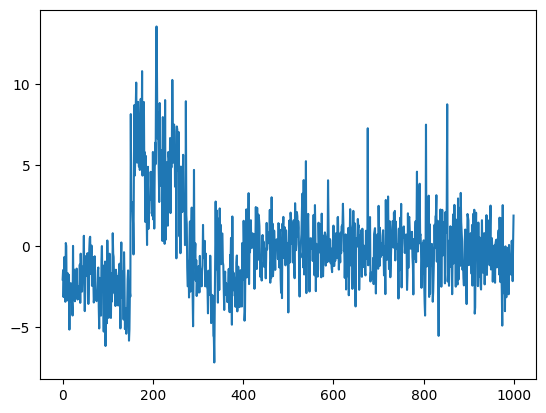

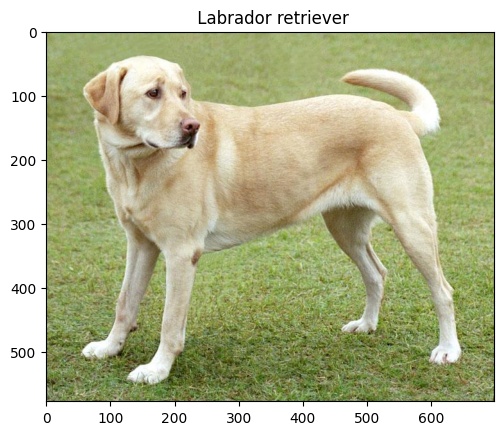

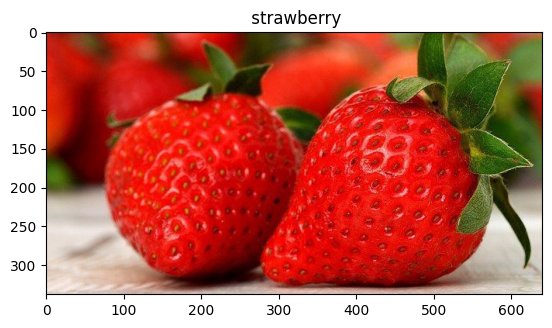

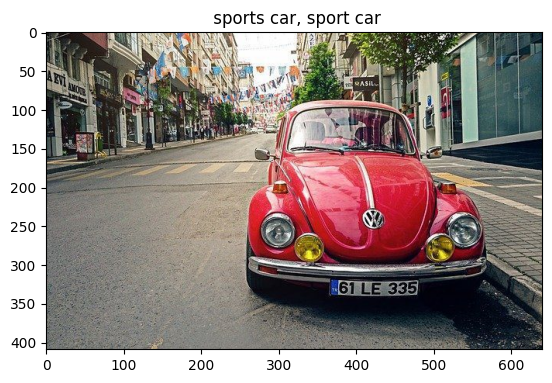

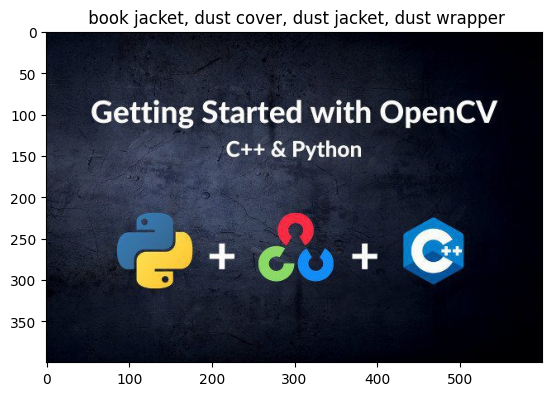

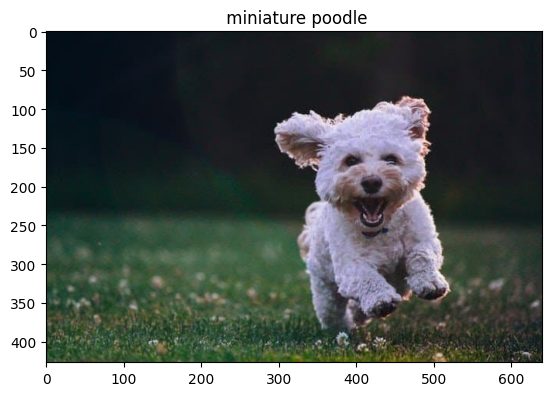

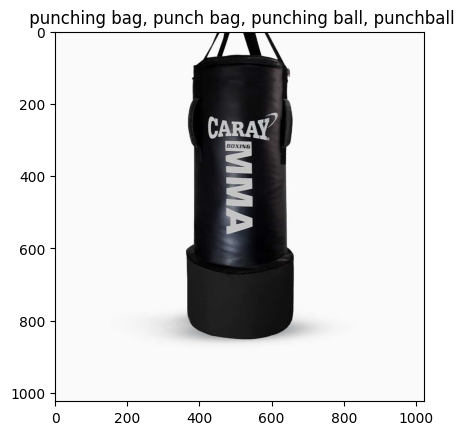

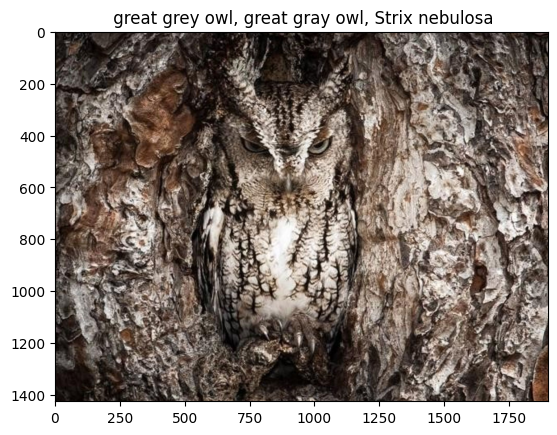

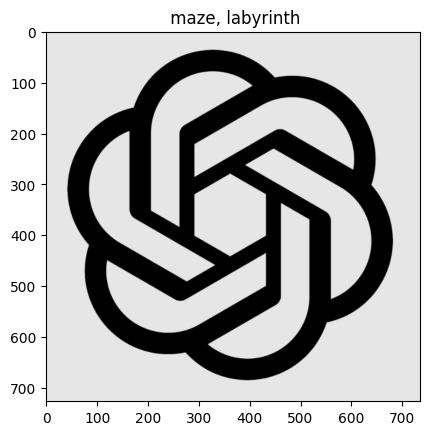

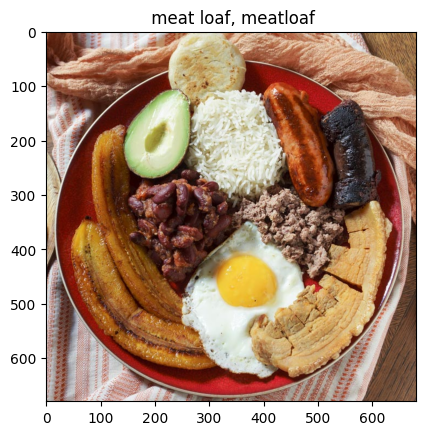

In [ ]:
batch_t=torch.cat([torch.unsqueeze(transform(im),0) for im in img], axis=0)
print(batch_t.shape)
resnet.eval()
out = resnet(batch_t)
print(out.shape)

plt.figure()
plt.plot(out.detach().numpy()[0])

_, index = torch.max(out, 1)
index=index.numpy()
i=0
for ind in index:
  plt.figure()
  plt.imshow(img[i])
  plt.title(clases[ind])
  i+=1


torch.Size([64, 3, 7, 7])


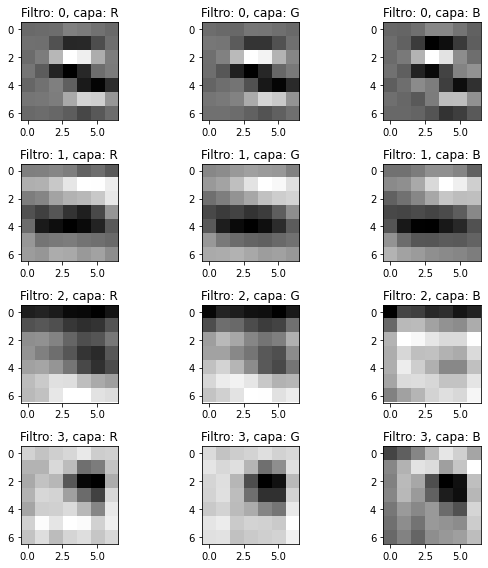

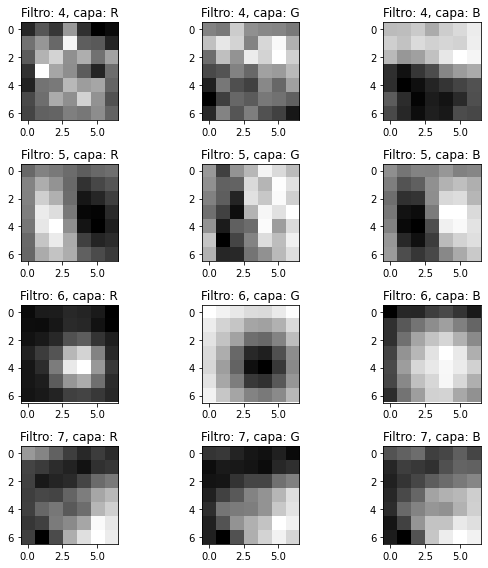

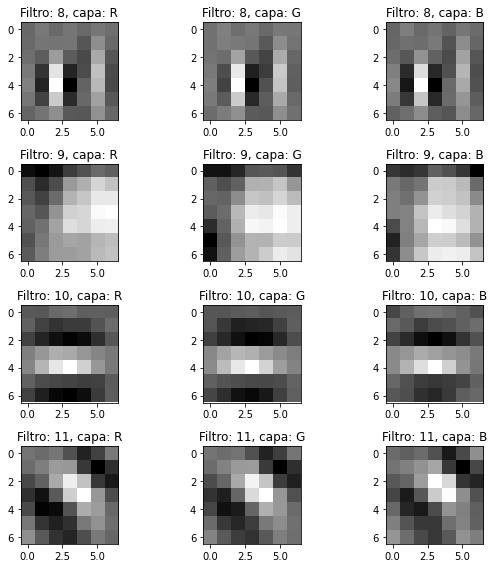

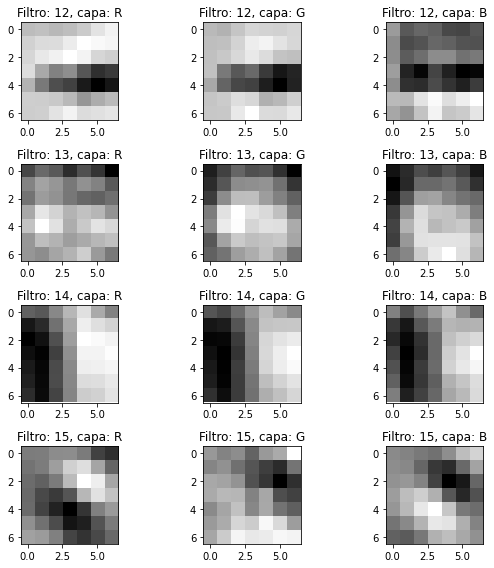

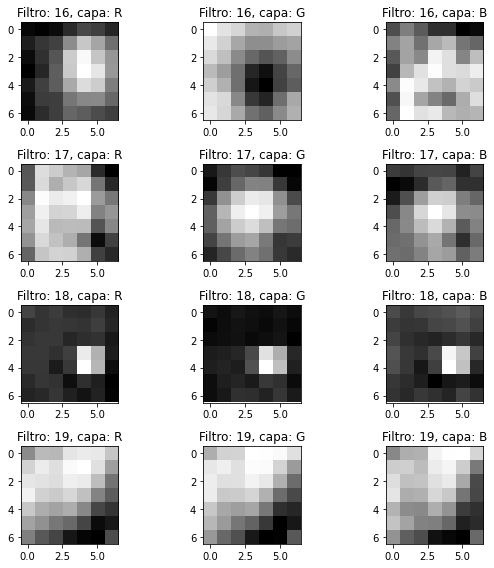

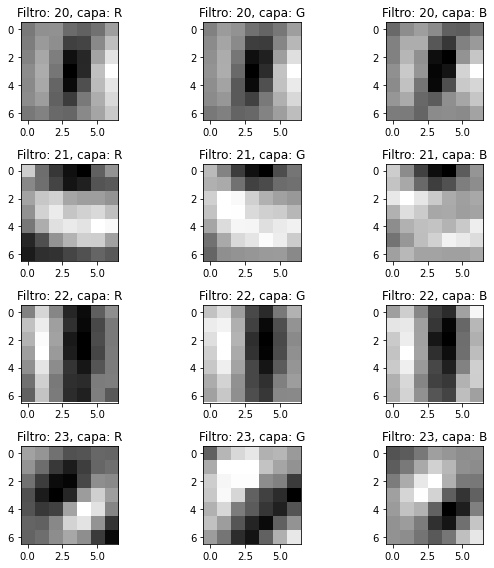

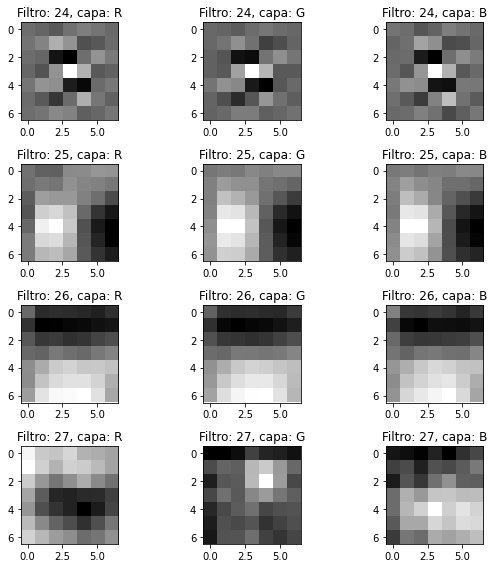

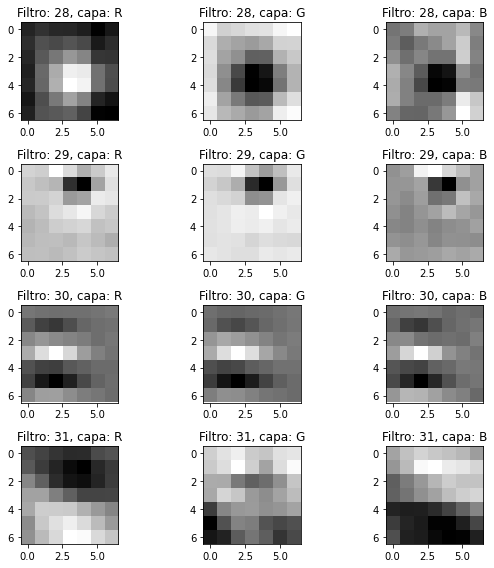

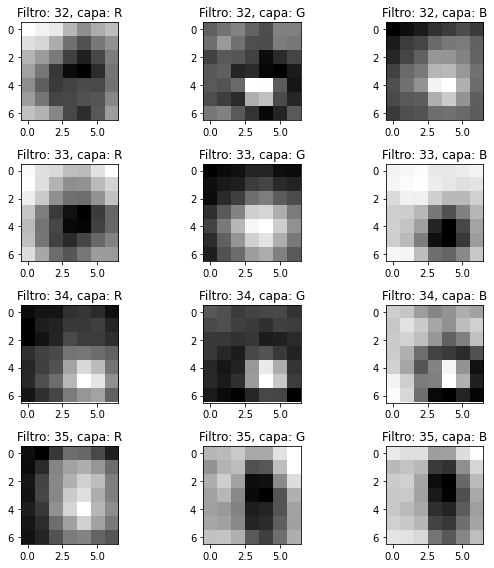

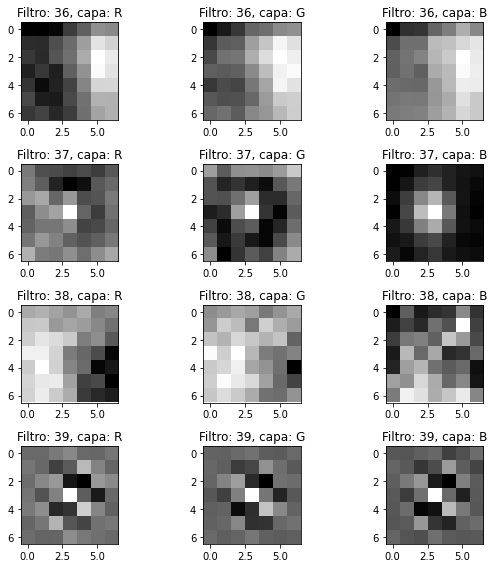

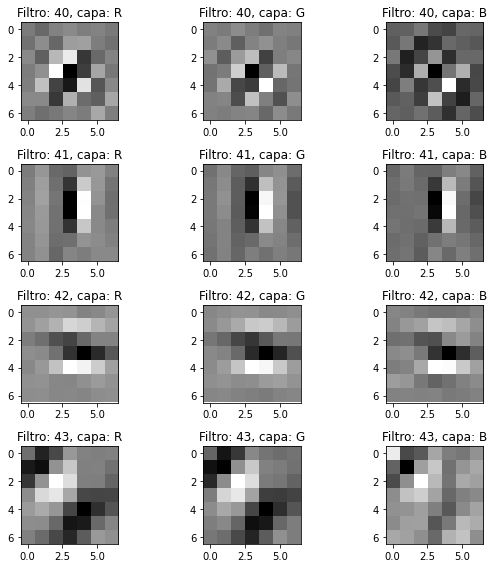

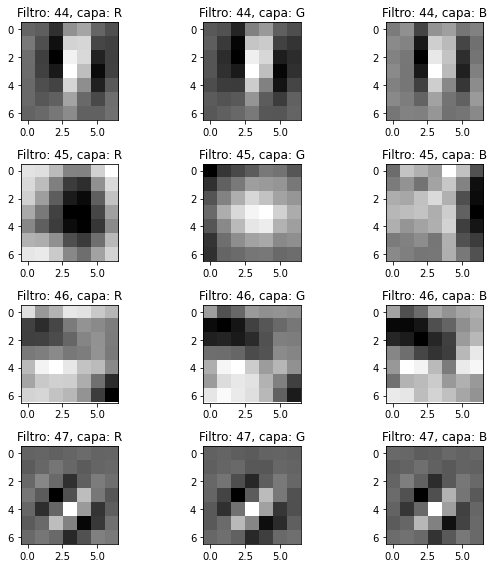

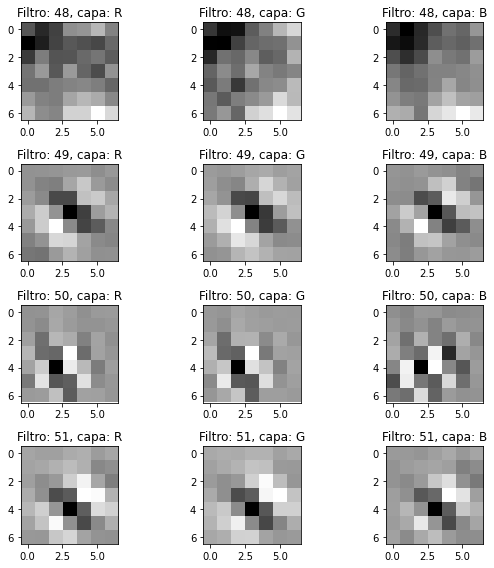

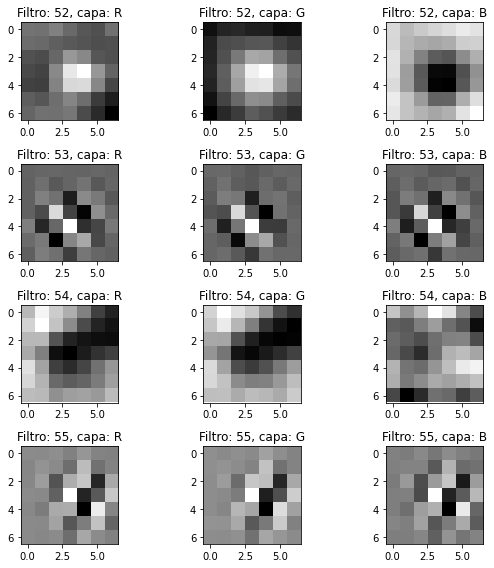

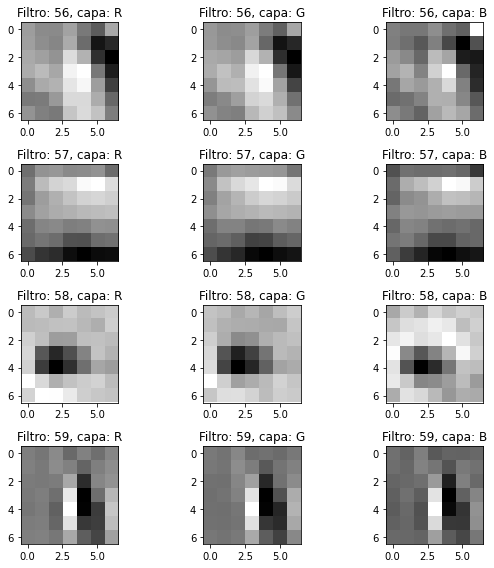

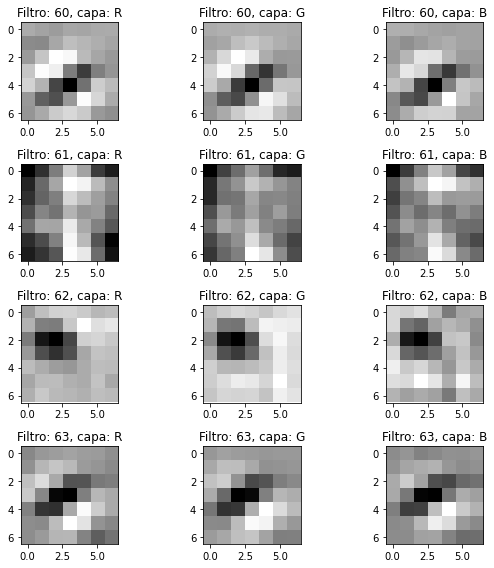

In [ ]:
print(resnet.conv1.weight.shape)
capas=['R','G','B']
plt.figure(figsize=(8,8))

with(torch.no_grad()):
  ind=1
  for i in range(64):
    a=i#np.random.randint(64)
    for b in range(3):
      if(ind==13):
        plt.tight_layout()
        plt.figure(figsize=(8,8))
        ind=1
      x=resnet.conv1.weight[a,b,:,:].numpy()
      #print(x)
      plt.subplot(4,3,ind)
      ind+=1
      plt.imshow(x, cmap='gray')
      plt.title('Filtro: '+str(a)+', capa: '+capas[b])
plt.tight_layout()
